In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/smart-mcq-solver-challenge/sample_submission.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv
/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv


In [2]:
train = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/train.csv")
test = pd.read_csv("/kaggle/input/competitions/smart-mcq-solver-challenge/test.csv")

In [3]:
print(test.columns)

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E'], dtype='object')


In [4]:

print(train.head())
print(train.columns)
print(train.shape)

print(test.head())
print(test.columns)
print(test.shape)

   id                                             prompt  \
0   1  Pick the best possible answer: What is Martin ...   
1   2        What is accelerator-based light-ion fusion?   
2   3  Determine the correct option: What is the term...   
3   4  Select the most accurate option: What is Marti...   
4   5  Identify the correct statement: What is the co...   

                                                   A  \
0  Martin Heidegger believes that humans exist wi...   
1  Accelerator-based light-ion fusion is a techni...   
2                                       Blueshifting   
3  Martin Heidegger believes that humans exist wi...   
4  Simultaneity is relative, meaning that two eve...   

                                                   B  \
0  Martin Heidegger believes that humans do not e...   
1  Accelerator-based light-ion fusion is a techni...   
2                                        Redshifting   
3  Martin Heidegger believes that humans do not e...   
4  Simultaneity is rel

Train shape: (2000, 8)
Test shape: (500, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      2000 non-null   int64 
 1   prompt  2000 non-null   object
 2   A       2000 non-null   object
 3   B       2000 non-null   object
 4   C       2000 non-null   object
 5   D       2000 non-null   object
 6   E       2000 non-null   object
 7   answer  2000 non-null   object
dtypes: int64(1), object(7)
memory usage: 125.1+ KB
None
                id
count  2000.000000
mean   1000.500000
std     577.494589
min       1.000000
25%     500.750000
50%    1000.500000
75%    1500.250000
max    2000.000000
answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64
id        0
prompt    0
A         0
B         0
C         0
D         0
E         0
answer    0
dtype: int64


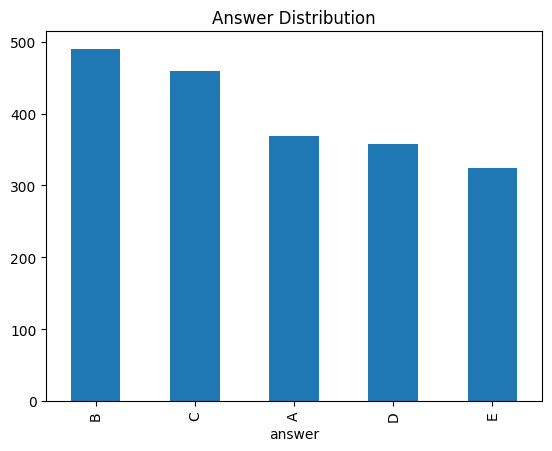

In [5]:
import pandas as pd 

import matplotlib.pyplot as plt   

# Basic info like shape, info and some basic stats like min max median and mean using describe()

print(f"Train shape: {train.shape}") 

print(f"Test shape: {test.shape}") 

print(train.info()) 

print(train.describe()) 

  

# Check answer distribution 

print(train['answer'].value_counts()) 

train['answer'].value_counts().plot(kind='bar') 

plt.title('Answer Distribution') 



  

# Check for missing values in training set

print(train.isnull().sum())

In [6]:
# # Question length analysis 

train['prompt_len'] = train['prompt'].str.len() 

print(train['prompt_len'].describe())

count    2000.000000
mean      117.669500
std        44.408674
min        19.000000
25%        87.750000
50%       111.000000
75%       141.000000
max       337.000000
Name: prompt_len, dtype: float64


In [7]:
train.columns

Index(['id', 'prompt', 'A', 'B', 'C', 'D', 'E', 'answer', 'prompt_len'], dtype='object')

In [8]:
train["answer"].value_counts()

answer
B    490
C    459
A    369
D    358
E    324
Name: count, dtype: int64

In [9]:
!pip install -q transformers==4.46.3 datasets accelerate sentencepiece

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 32.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 70.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
c

In [10]:
############  from here the main DeBERTA starts ############

In [11]:
# essential imports

import os
import gc
import torch
import numpy as np
import pandas as pd

from datasets import Dataset

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)

2026-06-12 09:41:20.952318: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781257281.167783      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781257281.226322      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781257281.737500      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781257281.737538      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781257281.737541      23 computation_placer.cc:177] computation placer alr

In [12]:
import random
from transformers import set_seed

SEED = 2025   # CHANGE THIS

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

set_seed(SEED)

print("Running Seed:", SEED)

Running Seed: 2025


In [13]:
# GPU CHECK

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [14]:
MODEL_NAME = "microsoft/deberta-v3-base"

MAX_LEN = 384

OPTIONS = ["A", "B", "C", "D", "E"]

In [15]:
# BUILD DATASET

def build_dataset(df, train_mode=True):

    rows = []

    for _, row in df.iterrows():

        question = str(row["prompt"])

        for option in OPTIONS:

            text = f"""
Question:
{question}

Candidate Answer:
{row[option]}

Is this the correct answer?
"""

            sample = {
                "text": text,
                "option": option
            }

            if train_mode:

                sample["label"] = (
                    1
                    if row["answer"] == option
                    else 0
                )

            rows.append(sample)

    return pd.DataFrame(rows)

In [16]:
# CREATE BINARY TRAINING DATA

binary_df = build_dataset(train)

print("Binary Dataset Shape:", binary_df.shape)

display(binary_df.head())

Binary Dataset Shape: (10000, 3)


,text,option,label
0,\nQuestion:\nPick the best possible answer: Wh...,A,0
1,\nQuestion:\nPick the best possible answer: Wh...,B,1
2,\nQuestion:\nPick the best possible answer: Wh...,C,0
3,\nQuestion:\nPick the best possible answer: Wh...,D,0
4,\nQuestion:\nPick the best possible answer: Wh...,E,0


In [17]:
# TRAIN / VALID SPLIT

train_df, valid_df = train_test_split(
    binary_df,
    test_size=0.20,
    random_state=SEED,
    stratify=binary_df["label"]
)

print("Train DF:", train_df.shape)
print("Valid DF:", valid_df.shape)

Train DF: (8000, 3)
Valid DF: (2000, 3)


In [18]:
# TOKENIZER

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME
)

def tokenize(batch):

    return tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LEN
    )

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/convert_slow_tokenizer.py:561: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


In [19]:
# HUGGINGFACE DATASETS

train_ds = Dataset.from_pandas(
    train_df.reset_index(drop=True)
)

valid_ds = Dataset.from_pandas(
    valid_df.reset_index(drop=True)
)

In [20]:
# TOKENIZATION

train_ds = train_ds.map(
    tokenize,
    batched=True
)

valid_ds = valid_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [21]:
# TORCH FORMAT

train_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

valid_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "label"
    ]
)

print(train_ds)
print(valid_ds)

Dataset({
    features: ['text', 'option', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 8000
})
Dataset({
    features: ['text', 'option', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2000
})


In [22]:
# METRICS

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    preds = np.argmax(
        logits,
        axis=1
    )

    acc = accuracy_score(
        labels,
        preds
    )

    f1 = f1_score(
        labels,
        preds
    )

    return {
        "accuracy": acc,
        "f1": f1
    }

In [23]:
# MODEL

model = (
    AutoModelForSequenceClassification
    .from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
)

print("Model Loaded")

pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-base and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model Loaded


In [24]:
# TRAINING ARGUMENTS


training_args = TrainingArguments(

    output_dir="deberta_model",

    overwrite_output_dir=True,

    
    # TRAINING
   

    num_train_epochs=5,

    learning_rate=1e-5,

    weight_decay=0.01,

    warmup_ratio=0.10,

    lr_scheduler_type="cosine",

    
    # BATCH SIZE
    

    per_device_train_batch_size=4,

    per_device_eval_batch_size=8,

    gradient_accumulation_steps=2,

   
    # MIXED PRECISION
   

    fp16=True,

  
    # EVALUATION
   

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,


    # LOGGING
  

    logging_steps=50,

    save_total_limit=2,

    report_to="none"
)

In [25]:
# TRAINER

trainer = Trainer(

    model=model,

    args=training_args,

    train_dataset=train_ds,

    eval_dataset=valid_ds,

    compute_metrics=compute_metrics
)

In [26]:
# TRAIN

print("\nStarting Training...\n")

trainer.train()

print("\nTraining Complete")


Starting Training...



/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.450900,0.459082,0.800000,0.000000
2,0.252400,0.224526,0.922000,0.782123
3,0.165500,0.131798,0.952000,0.882641
4,0.171000,0.110793,0.973000,0.932161
5,0.145900,0.104437,0.981000,0.951407


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector


Training Complete


In [27]:
# SAVE MODEL

MODEL_SAVE_PATH = (
    f"/kaggle/working/deberta_model_seed_{SEED}"
)
trainer.save_model(
    MODEL_SAVE_PATH
)

tokenizer.save_pretrained(
    MODEL_SAVE_PATH
)

print("\nModel Saved Successfully")


Model Saved Successfully


In [28]:
# VALIDATION PROBABILITIES
# (FOR FUTURE ENSEMBLING)


valid_predictions = trainer.predict(
    valid_ds
)

valid_logits = (
    valid_predictions.predictions
)

valid_probs = torch.softmax(
    torch.tensor(valid_logits),
    dim=1
).numpy()[:,1]

np.save(
    "/kaggle/working/deberta_val_probs.npy",
    valid_probs
)

print(
    "deberta_val_probs.npy saved"
)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


deberta_val_probs.npy saved


In [29]:
# CLEAN MEMORY


gc.collect()

torch.cuda.empty_cache()

print("GPU Cache Cleared")

GPU Cache Cleared


In [30]:
# BUILD TEST DATASET

test_binary = build_dataset(
    test,
    train_mode=False
)

print(
    "Test Binary Shape:",
    test_binary.shape
)

display(
    test_binary.head()
)

Test Binary Shape: (2500, 2)


,text,option
0,\nQuestion:\nPick the best possible answer: Wh...,A
1,\nQuestion:\nPick the best possible answer: Wh...,B
2,\nQuestion:\nPick the best possible answer: Wh...,C
3,\nQuestion:\nPick the best possible answer: Wh...,D
4,\nQuestion:\nPick the best possible answer: Wh...,E


In [31]:
# CONVERT TO HF DATASET

test_ds = Dataset.from_pandas(
    test_binary.reset_index(drop=True)
)

In [32]:
# TOKENIZE

test_ds = test_ds.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

In [33]:
# TORCH FORMAT

test_ds.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask"
    ]
)

print(test_ds)

Dataset({
    features: ['text', 'option', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 2500
})


In [34]:
# PREDICT TEST

print(
    "\nGenerating Test Predictions...\n"
)

test_predictions = trainer.predict(
    test_ds
)


Generating Test Predictions...



In [35]:
# EXTRACT LOGITS

test_logits = (
    test_predictions.predictions
)

print(
    "Logits Shape:",
    test_logits.shape
)

Logits Shape: (2500, 2)


In [36]:
# CONVERT TO PROBABILITIES

test_probs = torch.softmax(
    torch.tensor(test_logits),
    dim=1
).numpy()[:,1]

print(
    "Probabilities Shape:",
    test_probs.shape
)

Probabilities Shape: (2500,)


In [37]:
# SAVE PROBABILITIES
# FOR FUTURE ENSEMBLE


np.save(
    f"/kaggle/working/deberta_probs_seed_{SEED}.npy",
    test_probs
)
print(
    "deberta_probs.npy saved"
)

deberta_probs.npy saved


In [38]:
# CREATE TOP-3 PREDICTIONS

OPTIONS = [
    "A",
    "B",
    "C",
    "D",
    "E"
]

final_predictions = []

for i in range(len(test)):

    scores = test_probs[
        i*5:(i+1)*5
    ]

    top3 = np.argsort(
        scores
    )[::-1][:3]

    prediction = " ".join(
        [
            OPTIONS[idx]
            for idx in top3
        ]
    )

    final_predictions.append(
        prediction
    )

In [39]:
# SUBMISSION

submission = pd.DataFrame({

    "ID":
    test["id"],

    "Prediction":
    final_predictions
})

print(
    "\nSubmission Preview:"
)

display(
    submission.head(10)
)


Submission Preview:


,ID,Prediction
0,1,A E B
1,2,B C A
2,3,B E D
3,4,E C D
4,5,C D A
5,6,D B C
6,7,E A D
7,8,B C E
8,9,C D A
9,10,B E D


In [40]:
# # SAVE SUBMISSION

# submission.to_csv(
#     "/kaggle/working/submission.csv",
#     index=False
# )

# print(
#     "\nsubmission.csv saved"
# )

submission.to_csv(
    f"/kaggle/working/deberta_seed_{SEED}.csv",
    index=False
)

submission.to_csv(
    "/kaggle/working/submission.csv",
    index=False
)

In [41]:
# VERIFY FILES

print(
    "\nFiles in /kaggle/working"
)

import os

for file in os.listdir(
    "/kaggle/working"
):

    print(file)


Files in /kaggle/working
deberta_seed_2025.csv
deberta_model_seed_2025
deberta_model
deberta_probs_seed_2025.npy
deberta_val_probs.npy
submission.csv
__notebook__.ipynb


In [42]:
# FINAL CHECKS


print(
    "\nSubmission Shape:",
    submission.shape
)

print(
    "\nUnique Predictions:"
)

print(
    submission["Prediction"]
    .head(20)
    .tolist()
)


Submission Shape: (500, 2)

Unique Predictions:
['A E B', 'B C A', 'B E D', 'E C D', 'C D A', 'D B C', 'E A D', 'B C E', 'C D A', 'B E D', 'A B C', 'D E C', 'C A B', 'C B E', 'E D B', 'A C D', 'E D C', 'B D E', 'A C B', 'D B C']


In [43]:
# KAGGLE SUBMISSION CHECK


assert os.path.exists(
    "/kaggle/working/submission.csv"
), "submission.csv not found!"

print(
    "\nREADY FOR KAGGLE SUBMISSION"
)

print(
    "/kaggle/working/submission.csv"
)


READY FOR KAGGLE SUBMISSION
/kaggle/working/submission.csv


In [44]:
# # OPTIONAL:
# # CHECK PROBABILITY FILE

# assert os.path.exists(
#     "/kaggle/working/deberta_probs.npy"
# )

# print(
#     "deberta_probs.npy saved successfully"
# )

In [45]:
!ls -lah /kaggle/working

total 156K
drwxr-xr-x 4 root root 4.0K Jun 12 10:36 .
drwxr-xr-x 8 root root 4.0K Jun 12 09:40 ..
drwxr-xr-x 4 root root 4.0K Jun 12 10:34 deberta_model
drwxr-xr-x 2 root root 4.0K Jun 12 10:35 deberta_model_seed_2025
-rw-r--r-- 1 root root 9.9K Jun 12 10:36 deberta_probs_seed_2025.npy
-rw-r--r-- 1 root root 4.8K Jun 12 10:36 deberta_seed_2025.csv
-rw-r--r-- 1 root root 8.0K Jun 12 10:35 deberta_val_probs.npy
---------- 1 root root 104K Jun 12 10:36 __notebook__.ipynb
-rw-r--r-- 1 root root 4.8K Jun 12 10:36 submission.csv


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [46]:
!ls -lah /kaggle/working

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


total 160K
drwxr-xr-x 4 root root 4.0K Jun 12 10:36 .
drwxr-xr-x 8 root root 4.0K Jun 12 09:40 ..
drwxr-xr-x 4 root root 4.0K Jun 12 10:34 deberta_model
drwxr-xr-x 2 root root 4.0K Jun 12 10:35 deberta_model_seed_2025
-rw-r--r-- 1 root root 9.9K Jun 12 10:36 deberta_probs_seed_2025.npy
-rw-r--r-- 1 root root 4.8K Jun 12 10:36 deberta_seed_2025.csv
-rw-r--r-- 1 root root 8.0K Jun 12 10:35 deberta_val_probs.npy
---------- 1 root root 105K Jun 12 10:36 __notebook__.ipynb
-rw-r--r-- 1 root root 4.8K Jun 12 10:36 submission.csv
